In [1]:
# ==============================================================================
# PIPELINE 6: Unsupervised Learning (Market Segmentation & Clustering)
# ==============================================================================
import pandas as pd

# Importing the explicit functions from our refactored module
from src.training.unsupervised import find_optimal_k, train_kmeans, train_dbscan, train_gmm
from src.training.evaluation import evaluate_clustering
from src.training.visualization import plot_cluster_profiles, plot_cluster_scatter_2d, plot_categorical_profiling_heatmap

pd.set_option('display.max_columns', None)

df_ml = pd.read_parquet("data/prepared/ted_prepared.parquet")
print(f"Initial dataset shape: {df_ml.shape}")

Initial dataset shape: (2425527, 28)


In [3]:
# ------------------------------------------------------------------------------
# STEP 1: Feature Setup (Winner of A/B Test: Structural Features Only)
# ------------------------------------------------------------------------------
# Based on prior experiments, we drop high-cardinality nominal data (Country, Sector) 
# to avoid the Curse of Dimensionality, focusing solely on contract size and competition.

categorical_cols = ['ISO_COUNTRY_CODE', 'CAE_TYPE', 'MAIN_ACTIVITY', 'CPV'] # for profiling

numeric_cols = [ # for clustering
    'TARGET_AWARD_VALUE_EUR', 'LOT_AWARD_VALUE_EUR', 'NUMBER_OF_TENDERS', 
    'LOTS_NUMBER', 'DURATION', 'PREPARATION_DAYS', 'NUTS_REGION_COUNT'
]

df_cluster = df_ml[numeric_cols + categorical_cols].dropna(subset=numeric_cols).copy()

# Automatically determine the ideal cluster count via Silhouette Analysis
best_k = find_optimal_k(df_cluster, categorical_cols=[], numeric_cols=numeric_cols, max_k=6)


Searching for optimal k (2 to 6)...
  -> k=2: Silhouette = 0.2169
  -> k=3: Silhouette = 0.2209
  -> k=4: Silhouette = 0.2472
  -> k=5: Silhouette = 0.2437
  -> k=6: Silhouette = 0.2449
 -> Recommended cluster count: 4



Initiating K-MEANS Clustering...

--- RESULTS: K-MEANS ---

--- Clustering Metrics ---
Silhouette Score:      0.2456 (Higher is better, max 1)
Davies-Bouldin Index:  1.2233 (Lower is better, min 0)
Calinski-Harabasz:     5,952.8 (Higher is better)


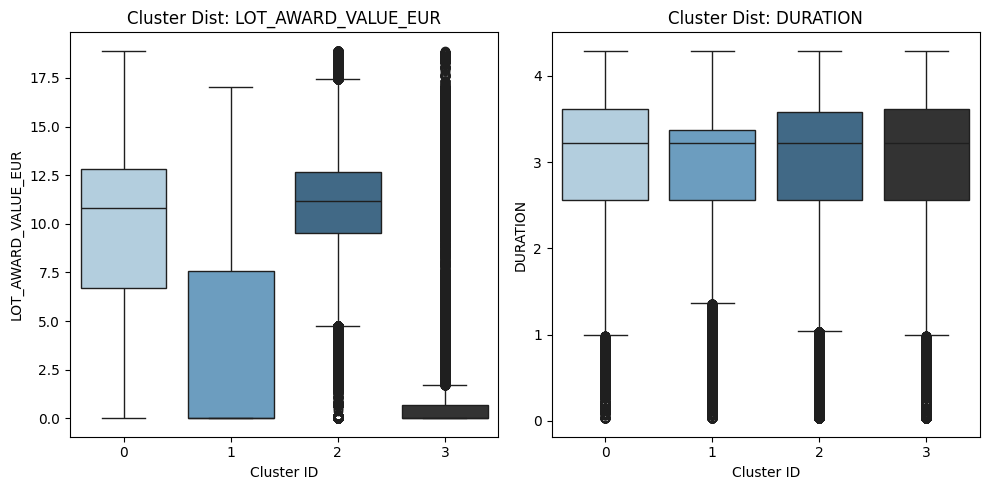

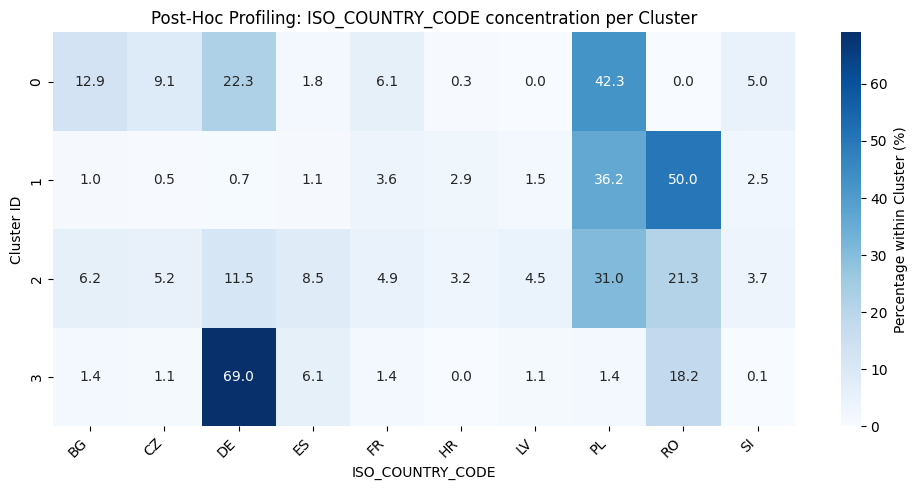

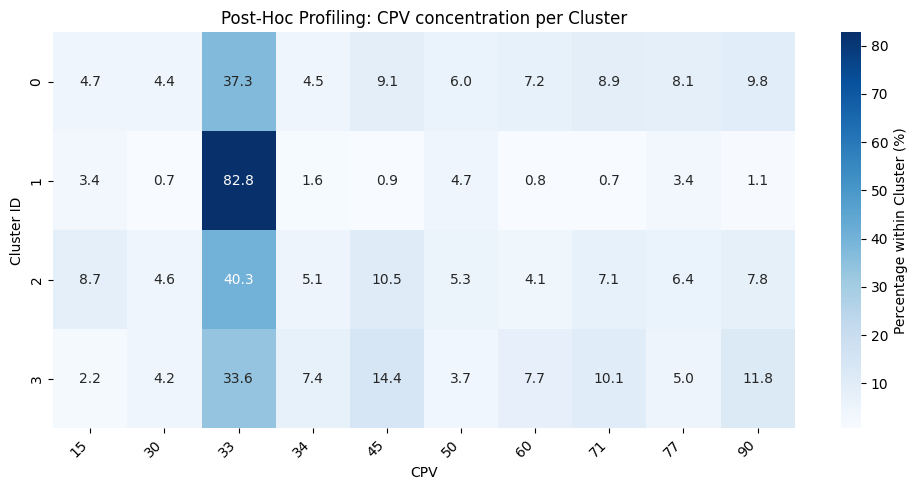

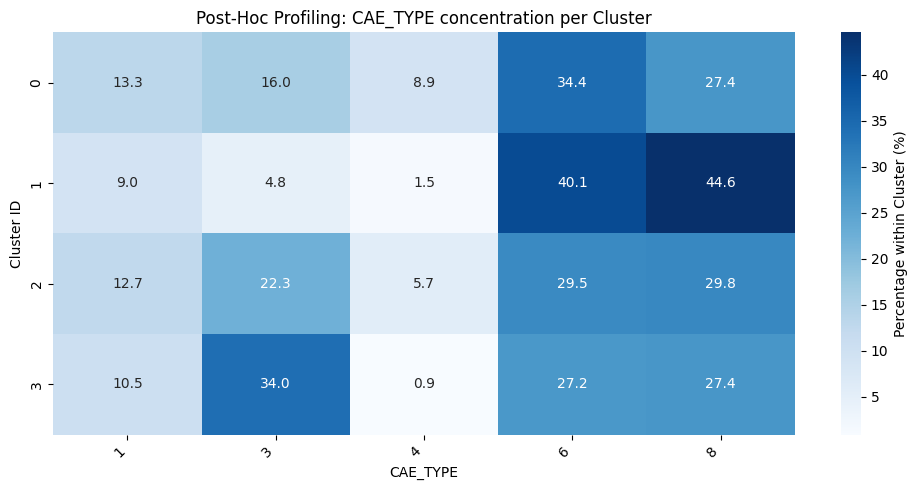

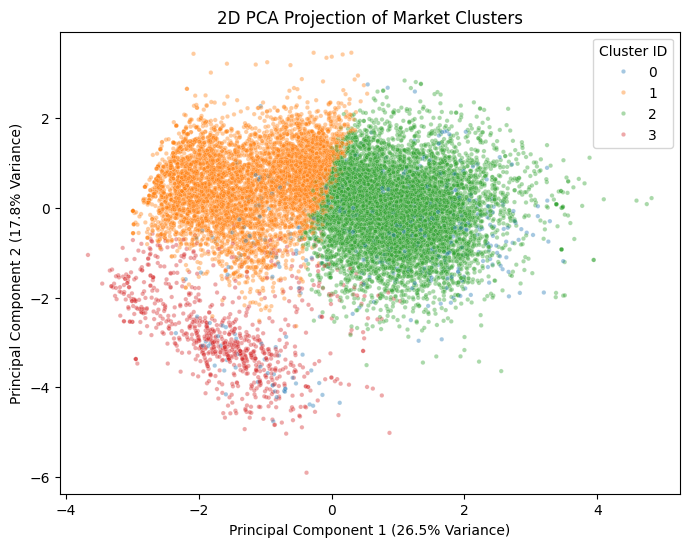

In [4]:
# ------------------------------------------------------------------------------
# STEP 2: Model 1 - K-Means Clustering
# ------------------------------------------------------------------------------
df_km, labels_km, X_proc_km, _ = train_kmeans(
    df=df_cluster, 
    categorical_cols=[], 
    numeric_cols=numeric_cols, 
    n_clusters=best_k,
    n_init=15
)

print("\n--- RESULTS: K-MEANS ---")
evaluate_clustering(X_proc_km, labels_km, sample_size=25000)
df_km['CLUSTER'] = labels_km
plot_cluster_profiles(df_km, 'CLUSTER', ['LOT_AWARD_VALUE_EUR', 'DURATION'])
plot_categorical_profiling_heatmap(df_km, 'CLUSTER', 'ISO_COUNTRY_CODE', top_n=10)
plot_categorical_profiling_heatmap(df_km, 'CLUSTER', 'CPV', top_n=10)
plot_categorical_profiling_heatmap(df_km, 'CLUSTER', 'CAE_TYPE', top_n=5)
plot_cluster_scatter_2d(X_proc_km, labels_km, vis_sample_size=15000, point_alpha=0.4, point_size=10)


Initiating DBSCAN Clustering...
  -> PC Protection: Subsampling to 250,000 rows.

--- RESULTS: DBSCAN ---

--- Clustering Metrics ---
Silhouette Score:      0.5214 (Higher is better, max 1)
Davies-Bouldin Index:  0.7289 (Lower is better, min 0)
Calinski-Harabasz:     1,648.7 (Higher is better)


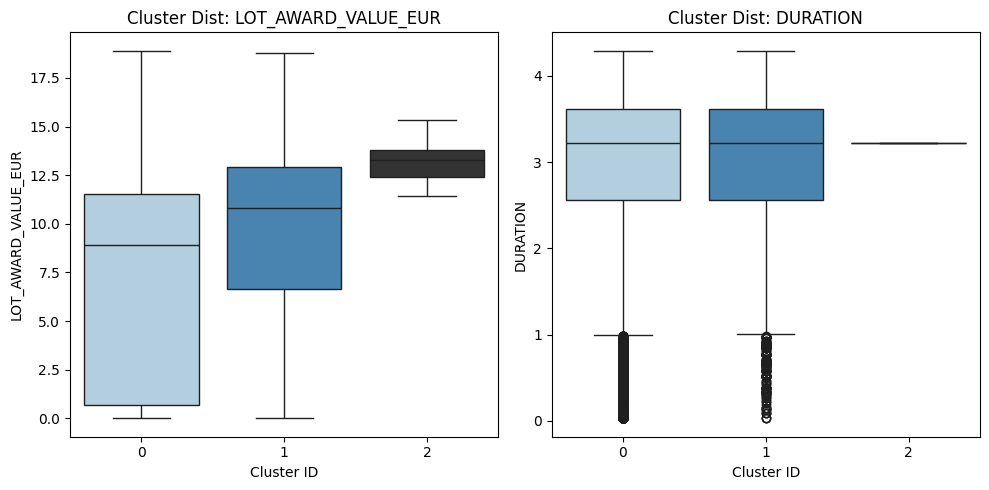

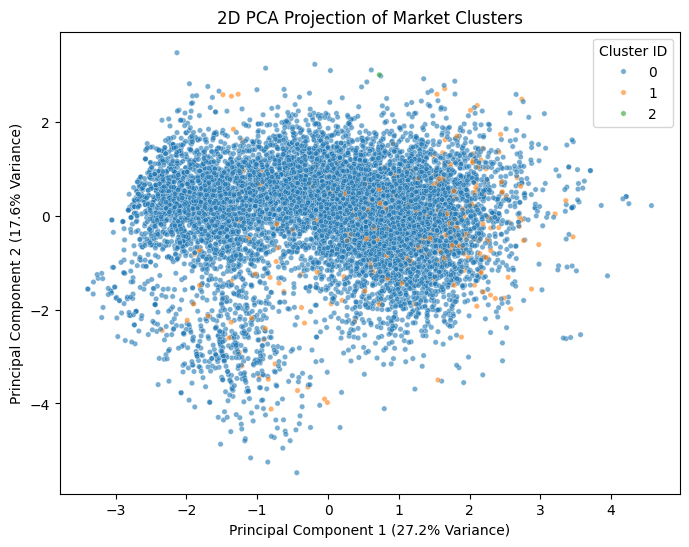

In [5]:
# ------------------------------------------------------------------------------
# STEP 3: Model 2 - DBSCAN
# ------------------------------------------------------------------------------
df_db, labels_db, X_proc_db, _ = train_dbscan(
    df=df_cluster, 
    categorical_cols=categorical_cols, 
    numeric_cols=numeric_cols, 
    eps=1.5,
    min_samples=20,
    max_rows=250000  # Explicitly controlling the PC protection limit
)

print("\n--- RESULTS: DBSCAN ---")
evaluate_clustering(X_proc_db, labels_db)
df_db['CLUSTER'] = labels_db

if len(set(labels_db)) > 1:
    plot_cluster_profiles(df_db[df_db['CLUSTER'] != -1], 'CLUSTER', ['LOT_AWARD_VALUE_EUR', 'DURATION'])
    plot_cluster_scatter_2d(X_proc_db[labels_db != -1], labels_db[labels_db != -1])


Initiating GMM Clustering...
  -> PC Protection: Subsampling to 250,000 rows.

--- RESULTS: GMM ---

--- Clustering Metrics ---
Silhouette Score:      0.2069 (Higher is better, max 1)
Davies-Bouldin Index:  2.3148 (Lower is better, min 0)
Calinski-Harabasz:     4,005.7 (Higher is better)


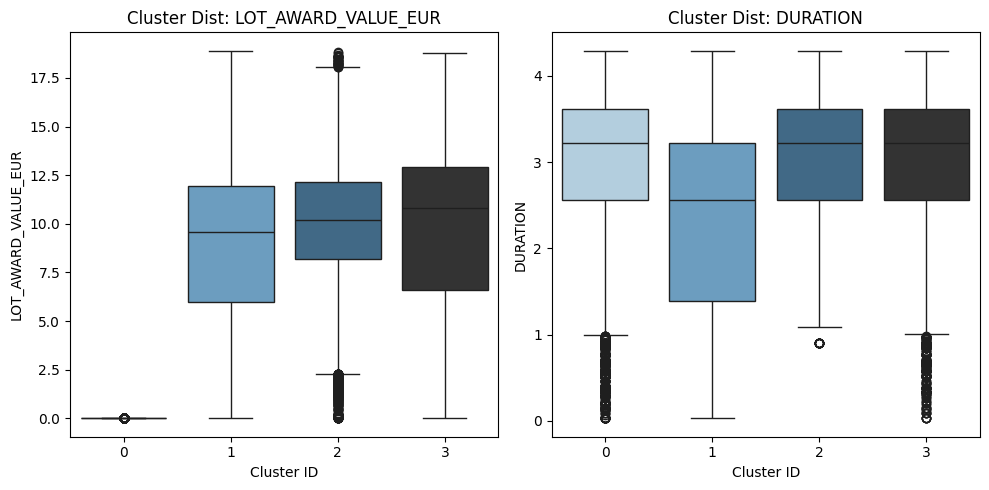

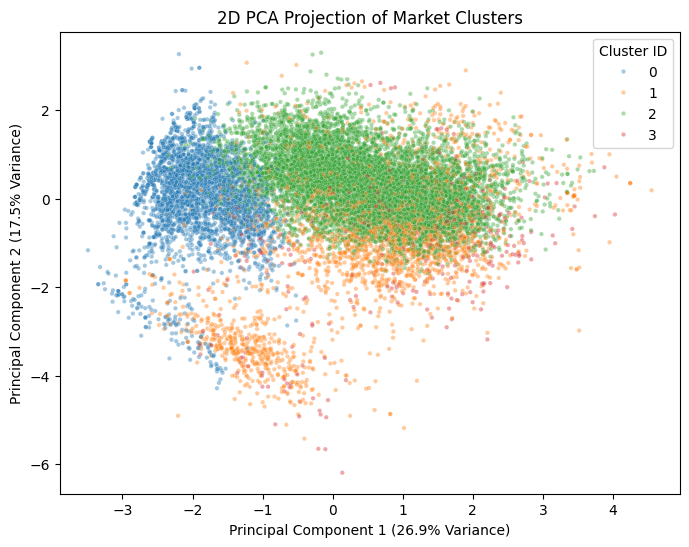

In [6]:
# ------------------------------------------------------------------------------
# STEP 4: Model 3 - Gaussian Mixture Model
# ------------------------------------------------------------------------------
df_gmm, labels_gmm, X_proc_gmm, _ = train_gmm(
    df=df_cluster, 
    categorical_cols=categorical_cols, 
    numeric_cols=numeric_cols, 
    n_clusters=best_k,
    covariance_type='full', 
    n_init=3,
    max_rows=250000  # Lowered memory footprint to allow 'full' covariance
)

print("\n--- RESULTS: GMM ---")
evaluate_clustering(X_proc_gmm, labels_gmm, sample_size=25000)
df_gmm['CLUSTER'] = labels_gmm
plot_cluster_profiles(df_gmm, 'CLUSTER', ['LOT_AWARD_VALUE_EUR', 'DURATION'])
plot_cluster_scatter_2d(X_proc_gmm, labels_gmm, vis_sample_size=15000, point_alpha=0.4, point_size=10)